# Machine Learning - Assignment 1

## Naive Bayes learning algorithm for binary classification, Cross-validation, and ROC-Curves

The aim of the assignment is to implement:

* Naive Bayes learning algorithm for binary classification tasks
* Visualization to plot a ROC-curve
* A cross-validation test
* Visualization of the average ROC-curve of a cross-validation test

Follow the instructions and implement what is missing to complete the assignment. Some functions have been started to help you a little bit with the inputs or outputs of the function.

**Note:** You might need to go back and forth during your implementation of the code. The structure is set up to make implementation easier, but how you return values from the different functions might vary, and you might find yourself going back and change something to make it easier later on.

## Assignment preparations

We help you out with importing the libraries and reading the data.

Look at the output to get an idea of how the data is structured.

**IMPORTANT NOTE:** You may not import any more libraries than the ones already imported!

# Imports and data loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib   b.pyplot as plt
from math import e, pi

In [199]:
# Load the Iris dataset from CSV and convert to numpy array
data = pd.read_csv("iris.csv").to_numpy()

In [200]:
# Map string labels to integers
mapped, index, unique_arr = np.unique(data[:, -1], return_index=True, return_inverse=True)
data[:, -1] = unique_arr

In [201]:
# Split full dataset into three classes for reference
iris_setosa, iris_versicolor, iris_virginica = np.split(data, index[1:])

In [202]:

# Print sample of dataset
print(f"Full data array (features and labels):\n{iris_setosa[:3]}\n\n")
print(f"Train features (first 4 columns):\n{iris_setosa[:3, :-1]}\n\n")
print(f"Labels (last column):\n{iris_setosa[:3, -1:]}\n\n")
print(f"Label names:\n{[[numb, name] for numb, name in enumerate(mapped)]}")


Full data array (features and labels):
[[5.1 3.5 1.4 0.2 0]
 [4.9 3.0 1.4 0.2 0]
 [4.7 3.2 1.3 0.2 0]]


Train features (first 4 columns):
[[5.1 3.5 1.4 0.2]
 [4.9 3.0 1.4 0.2]
 [4.7 3.2 1.3 0.2]]


Labels (last column):
[[0]
 [0]
 [0]]


Label names:
[[0, 'Iris-setosa'], [1, 'Iris-versicolor'], [2, 'Iris-virginica']]


# Print samples from the dataset

In [203]:
# Example print of the 3 first datapoints (similar as above):
iris_setosa[:3]

array([[5.1, 3.5, 1.4, 0.2, 0],
       [4.9, 3.0, 1.4, 0.2, 0],
       [4.7, 3.2, 1.3, 0.2, 0]], dtype=object)

## Data handling functions

As a start, we are going to implement some basic data handling functions to use in the future.

### 1) Split class into a train and test set

First, we need to be able to split the class into a train and test set.

For this assignment, we recommend a 80/20-split, that is 80% of the data is used for training, 20% is used for testing.

# Define a function to split the class data into train and test set

In [204]:
def train_test_split(class_data, train_ratio=0.8):

    np.random.shuffle(class_data)  # shuffle rows
    n_train = int(len(class_data) * train_ratio)
    train = class_data[:n_train]
    test = class_data[n_train:]
    return train, test


# Testing of the train_test_split function

In [205]:
train_setosa, test_setosa = train_test_split(iris_setosa, train_ratio=0.8)

In [206]:
# Print the shapes to check if split is correct
print("Setosa class split:")
print(f"\tTrain shape: {train_setosa.shape}")
print(f"\tTest shape: {test_setosa.shape}")

Setosa class split:
	Train shape: (40, 5)
	Test shape: (10, 5)


In [207]:
# Print a few samples to verify
print("First 3 training samples:")
print(train_setosa[:3])
print("\n\nFirst 3 test samples:")
print(test_setosa[:3])

First 3 training samples:
[[5.5 3.5 1.3 0.2 0]
 [5.4 3.9 1.7 0.4 0]
 [4.6 3.6 1.0 0.2 0]]


First 3 test samples:
[[4.5 2.3 1.3 0.3 0]
 [5.8 4.0 1.2 0.2 0]
 [4.8 3.4 1.6 0.2 0]]


### 2) Split data into features and labels

The data as shown above is not always the optimal shape. To help us keep track of things, we can split the data into its features and labels seperately.

Each class is 4 features and 1 label in the same array:

* **[feature 1, feature 2, feature 3, feature 4, label]**

It would help us later to have the features and labels in seperate arrays in the form:

* **[feature 1, feature 2, feature 3, feature 4]** and **[label]**

Here you are going to implement this functionallity.

# Define a function to split one class into its features and labels

In [208]:
def feature_label_split(data):
    features = data[:, :-1]  # all columns except last
    labels = data[:, -1]     # last column as 1D array
    return features, labels


We should first test the "**Feature_label_split**" function on one of the classes above (iris_setosa, etc...) to make sure it works properly.

# Testing of the class splitting function

In [209]:
# Split Setosa class into features and labels
features_setosa, labels_setosa = feature_label_split(iris_setosa)

In [210]:
# Print shapes to check
print("Setosa features and labels split:")
print(f"\tFeatures shape: {features_setosa.shape}")  # Should be (50, 4)
print(f"\tLabels shape: {labels_setosa.shape}")      # Should be (50,)

Setosa features and labels split:
	Features shape: (50, 4)
	Labels shape: (50,)


In [211]:
# Print first few samples to verify
print("First 3 feature rows:")
print(features_setosa[:3])
print("\n\nFirst 3 labels:")
print(labels_setosa[:3])


First 3 feature rows:
[[5.5 3.5 1.3 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.6 1.0 0.2]]


First 3 labels:
[0 0 0]


We should also try to **1)** first split a class into a train and test set, **2)** split each of these two into features and abels. In total there should be 4 arrays (2 feature and 2 label arrays).

# Create feature and label arrays for binary classification

In [212]:
# 1. Split each class into train and test
train_setosa, test_setosa = train_test_split(iris_setosa, train_ratio=0.8)
train_versicolor, test_versicolor = train_test_split(iris_versicolor, train_ratio=0.8)

In [213]:
# 2. Split training data into features and labels
X_train_setosa, y_train_setosa = feature_label_split(train_setosa)
X_train_versicolor, y_train_versicolor = feature_label_split(train_versicolor)

In [214]:
# 3. Combine the two classes into a single training set (features and labels)
X_train = np.vstack((X_train_setosa, X_train_versicolor))
y_train = np.hstack((y_train_setosa, y_train_versicolor))

In [215]:
# 4. Split testing data into features and labels
X_test_setosa, y_test_setosa = feature_label_split(test_setosa)
X_test_versicolor, y_test_versicolor = feature_label_split(test_versicolor)

In [216]:
# Combine the two classes into a single test set
X_test = np.vstack((X_test_setosa, X_test_versicolor))
y_test = np.hstack((y_test_setosa, y_test_versicolor))

In [217]:
# 5. Print shapes and sample outputs
print("Training features shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing features shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

print("\n\nFirst 3 training feature rows:\n", X_train[:3])
print("\nFirst 3 training labels:\n", y_train[:3])

print("\n\nFirst 3 testing feature rows:\n", X_test[:3])
print("\nFirst 3 testing labels:\n", y_test[:3])


Training features shape: (80, 4)
Training labels shape: (80,)
Testing features shape: (20, 4)
Testing labels shape: (20,)


First 3 training feature rows:
 [[5.1 3.8 1.6 0.2]
 [4.6 3.4 1.4 0.3]
 [4.8 3.4 1.9 0.2]]

First 3 training labels:
 [0 0 0]


First 3 testing feature rows:
 [[5.4 3.4 1.5 0.4]
 [5.2 3.4 1.4 0.2]
 [5.3 3.7 1.5 0.2]]

First 3 testing labels:
 [0 0 0]


Think a bit before going to the next task, what can easily go wrong in the above code?

## Naive Bayes learning algorithm

When implementing the Navie Bayes learning algorithm, we can break it down into its components similar to how Naive Bayes is formulated.

Common formulation:
$$
P(Y \mid X_i) = \frac{P(Y)\,P(X_i \mid Y)}{P(X_i)}
$$

In 'Plain English':
$$
\text{Posterior} = \frac{\text{Prior} \times \text{Likelihood}}{\text{Evidence}}
$$

In short, we are looking for the **posterior** based on the **prior**, **likelihood** and **evidence**.

In practice, we will calculate the **posterior** for each class and then we look for the class with the highest (max) **posterior**.

A great source of learning is the Wiki page and the example towards the end:
https://en.wikipedia.org/wiki/Naive_Bayes_classifier#Person_classification

Below are the components which are needed to calculate the posterior for each class.

### 3) Calculate feature statistics

First, we need to implement a function that returns feature statistics (means, standard deviation, and priors) for a single set of feature data for a single class. This is the equivalent of "training" the naive bayes model.

**Note 1:** Each feature for each class gets its own mean, standard deviation, and priors!

**Note 2:** The way you structure the functions (what is returned) shapes the remainder of the assignment.

# Define a function to calculate feature statistics for one class

In [218]:
def calculate_feature_statistics(feature_data):
    """
    Calculate mean, standard deviation, and prior for one class.
    """
    # Ensure proper numpy dtype
    feature_data = np.asarray(feature_data, dtype=np.float64)

    # Extract features (all columns except last)
    features = feature_data[:, :-1]

    mean = np.mean(features, axis=0)
    std = np.std(features, axis=0, ddof=0)
    prior = feature_data.shape[0] / total_samples

    return {
        "mean": mean,
        "std": std,
        "prior": prior
    }

To make sure the function works, we should test it before proceding.

# Test calculate_feature_statistics function

In [219]:
total_samples = X_train.shape[0]  # total number of samples in the training set

In [220]:
# Prepare feature + label data for one class (Setosa)
setosa_train_data = np.hstack((X_train_setosa, y_train_setosa.reshape(-1, 1)))

In [221]:
# Calculate feature statistics for Setosa
stats_setosa = calculate_feature_statistics(setosa_train_data)

In [222]:
# Print the results
print("Feature statistics for Setosa class:")
print(f"\tMean: {stats_setosa['mean']}")
print(f"\tStandard Deviation: {stats_setosa['std']}")
print(f"\tPrior: {stats_setosa['prior']}")


Feature statistics for Setosa class:
	Mean: [4.9475 3.36   1.4525 0.2375]
	Standard Deviation: [0.34057855 0.34842503 0.18572493 0.10413333]
	Prior: 0.5


### 4) Gaussian probability density function (Gaussian PDF)

Now we need to implement the gaussian probability density function to use for a single datapoint.

**Note:** Look at the imports in the first cell at the top, it has some math numbers for easy use here.

# Define a function to find Gaussian Probability Density

In [223]:
def gaussian_probability_density_function(x, mean, stdev):
    exponent = - ((x - mean) ** 2) / (2 * stdev**2)
    return (1 / (np.sqrt(2 * np.pi) * stdev)) * e**exponent

### 5) Testing Gaussian PDF

We should test it to make sure it works. Train it, using the "calculate_feature_statistics" function, on one of the dataset classes. Then, take one datapoint from the same class and use naive bayes gaussian to calculate one posterior for one class.

# Test Gaussian PDF function

In [224]:
# 1. Prepare total_samples for prior calculation
total_samples = X_train.shape[0]

In [225]:
# 2. Prepare feature + label data for Setosa class
setosa_train_data = np.hstack((X_train_setosa, y_train_setosa.reshape(-1, 1)))

In [226]:
# 3. Calculate feature statistics for Setosa
stats_setosa = calculate_feature_statistics(setosa_train_data)

In [227]:
# 4. Take one datapoint from Setosa training set to test
datapoint = X_train_setosa[0]  # first sample features only

In [228]:
# 5. Calculate Gaussian probability density for each feature
probabilities = []
for i in range(len(datapoint)):
    prob = gaussian_probability_density_function(
        x=datapoint[i],
        mean=stats_setosa['mean'][i],
        stdev=stats_setosa['std'][i]
    )
    probabilities.append(prob)

In [229]:
# 6. Combine feature probabilities (multiply or sum log for numerical stability)
# Here we just multiply for simplicity
posterior_likelihood = np.prod(probabilities) * stats_setosa['prior']

In [230]:
# 7. Print results
print("Datapoint features:", datapoint)
print("Individual feature probabilities:", probabilities)
print("Posterior likelihood for Setosa:", posterior_likelihood)


Datapoint features: [5.1 3.8 1.6 0.2]
Individual feature probabilities: [np.float64(1.0596334992710696), np.float64(0.515833923652295), np.float64(1.5670344217833616), np.float64(3.5905420111980755)]
Posterior likelihood for Setosa: 1.5377089173063287


As a test, take one datapoint from one of the other classes and see if the predicted probability changes.

# Test Gaussian PDF with a datapoint from another class

In [231]:
other_datapoint = X_train_versicolor[0]  # first sample of Versicolor

In [232]:
# Calculate Gaussian probability density for each feature using Setosa stats
other_probabilities = []
for i in range(len(other_datapoint)):
    prob = gaussian_probability_density_function(
        x=other_datapoint[i],
        mean=stats_setosa['mean'][i],
        stdev=stats_setosa['std'][i]
    )
    other_probabilities.append(prob)

In [233]:
# Combine feature probabilities and multiply by prior
other_posterior_likelihood = np.prod(other_probabilities) * stats_setosa['prior']

In [234]:
# Print results
print("Other class datapoint features (Versicolor):", other_datapoint)
print("Individual feature probabilities with Setosa stats:", other_probabilities)
print("Posterior likelihood for this datapoint (using Setosa stats):", other_posterior_likelihood)


Other class datapoint features (Versicolor): [5.7 3.0 4.2 1.2]
Individual feature probabilities with Setosa stats: [np.float64(0.10200634510745274), np.float64(0.6714075257789455), np.float64(6.465931990532884e-48), np.float64(1.0763094497265277e-18)]
Posterior likelihood for this datapoint (using Setosa stats): 2.3831516649432944e-67


Think a bit why the probability changes, what could affect the prediction?

## Prepare Naive Bayes for binary classification

### 6) Prepare the data for inference

Before we train and test the naive bayes for multiple classes, we should get our data in order.

Similar to how we did previously, we should now split two classes into a train and test set, you may choose which two classes freely.

# Prepare data for inference (binary classification)

In [235]:
# 1️⃣ Split each class into train and test sets
train_setosa, test_setosa = train_test_split(iris_setosa, train_ratio=0.8)
train_versicolor, test_versicolor = train_test_split(iris_versicolor, train_ratio=0.8)

In [236]:
# 2️⃣ Split training data into features and labels
X_train_setosa, y_train_setosa = feature_label_split(train_setosa)
X_train_versicolor, y_train_versicolor = feature_label_split(train_versicolor)

In [237]:
# 3️⃣ Combine the two classes into a single training set
X_train = np.vstack((X_train_setosa, X_train_versicolor))
y_train = np.hstack((y_train_setosa, y_train_versicolor))

In [238]:
# 4️⃣ Split test data into features and labels
X_test_setosa, y_test_setosa = feature_label_split(test_setosa)
X_test_versicolor, y_test_versicolor = feature_label_split(test_versicolor)

In [239]:
# Combine the two classes into a single test set
X_test = np.vstack((X_test_setosa, X_test_versicolor))
y_test = np.hstack((y_test_setosa, y_test_versicolor))

In [240]:
# 5️⃣ Print shapes and verify
print("Training features shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing features shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

print("\n\nFirst 3 training samples:")
print(X_train[:3], y_train[:3])

print("\n\nFirst 3 testing samples:")
print(X_test[:3], y_test[:3])


Training features shape: (80, 4)
Training labels shape: (80,)
Testing features shape: (20, 4)
Testing labels shape: (20,)


First 3 training samples:
[[4.8 3.4 1.6 0.2]
 [4.8 3.4 1.9 0.2]
 [5.3 3.7 1.5 0.2]] [0 0 0]


First 3 testing samples:
[[5.4 3.4 1.5 0.4]
 [4.8 3.1 1.6 0.2]
 [5.1 3.8 1.6 0.2]] [0 0 0]


### 7) Class A vs Class B for binary classification

We have to get the posterior from two classes and compare the two posteriors in order to make a propper prediction.

For this, we need a function that calculates the posteriors for each class in binary classification and outputs the one with the highest posterior.

**IMPORTANT NOTES**:
1) When we are calculating the **Likelihood**, we are multiplying a small for each feature, making the result very very small. This can be problematic if we have a lot of features. Because of this, to make the calculation numerically stable, we instead calculate the sum of log feature likelihood:
$$
\prod_{i} P(X_i \mid Y) \rightarrow \sum_{i} \text{log}( P(X_i \mid Y) )
$$
2) We are **not** calculating probabilities, we are calculating **priors** and **likelihoods**. A lot of people make this misstaken. **Priors** and **likelihoods** can be less or more than 1 (even when summed up) and this is normal behavior.


# Define a function for Naive Bayes prediction

In [241]:
def naive_bayes_prediction(data_point, feature_stats):
    """
    Compute posterior for each class and return predicted class
    """
    max_log_prob = -np.inf
    prediction_class = None

    for cls, stats in feature_stats.items():
        # Prior (use log)
        log_prob = np.log(stats["prior"])

        # Likelihood (sum log Gaussian PDF)
        for i in range(len(data_point)):
            log_prob += np.log(gaussian_probability_density_function(
                data_point[i], stats["mean"][i], stats["std"][i]
            ))

        # Choose class with max posterior
        if log_prob > max_log_prob:
            max_log_prob = log_prob
            prediction_class = cls

    return prediction_class

To test the function we need the feature statistics from the classes we choose.

**Note:** Choose the correct train/test set and the correct feature/label split!

# Calculate feature statistics for each class

In [242]:
# Make sure total_samples is defined for prior calculation
total_samples = X_train.shape[0]  # total number of training samples

In [243]:
# Combine features and labels for each class (needed for calculate_feature_statistics)
setosa_train_data = np.hstack((X_train_setosa, y_train_setosa.reshape(-1, 1)))
versicolor_train_data = np.hstack((X_train_versicolor, y_train_versicolor.reshape(-1, 1)))

In [244]:
# Calculate feature statistics for each class
stats_setosa = calculate_feature_statistics(setosa_train_data)
stats_versicolor = calculate_feature_statistics(versicolor_train_data)

In [245]:
# Store the statistics in a dictionary for easy access
feature_stats = {
    0: stats_setosa,       # assuming Setosa label = 0
    1: stats_versicolor    # assuming Versicolor label = 1
}

In [246]:
# Print the results to verify
print("Setosa statistics:")
print(f"\tMean: {stats_setosa['mean']}")
print(f"\tStd: {stats_setosa['std']}")
print(f"\tPrior: {stats_setosa['prior']}")

print("\n\nVersicolor statistics:")
print(f"\tMean: {stats_versicolor['mean']}")
print(f"\tStd: {stats_versicolor['std']}")
print(f"\tPrior: {stats_versicolor['prior']}")


Setosa statistics:
	Mean: [5.0125 3.4225 1.4625 0.245 ]
	Std: [0.33703672 0.3952768  0.17984368 0.10943034]
	Prior: 0.5


Versicolor statistics:
	Mean: [5.9475 2.77   4.235  1.31  ]
	Std: [0.50248756 0.27676705 0.48091059 0.18275667]
	Prior: 0.5


Now we should have implemented all the neccessary parts to train a naive bayes algorithm and do inference on it. Implement a small test workflow for two of your chosen classes.

# Test Naive Bayes prediction on the test set

In [247]:
def naive_bayes_prediction(data_point, feature_stats):
    """
    Predict the class for a single data point using Naive Bayes.
    feature_stats: dictionary of stats for each class (mean, std, prior)
    """
    posteriors = {}

    for cls, stats in feature_stats.items():
        mean = stats['mean']
        std = stats['std']
        prior = stats['prior']

        # Calculate likelihood for each feature
        likelihoods = []
        for i in range(len(data_point)):
            prob = gaussian_probability_density_function(
                x=data_point[i],
                mean=mean[i],
                stdev=std[i]
            )
            likelihoods.append(prob)

        # Multiply probabilities and multiply by prior (posterior)
        posteriors[cls] = np.prod(likelihoods) * prior

    # Return class with highest posterior
    return max(posteriors, key=posteriors.get)

In [248]:
# -----------------------------
# Make predictions on the test set
# -----------------------------
predictions = np.array([naive_bayes_prediction(x, feature_stats) for x in X_test])

In [249]:
# -----------------------------
# Print predicted vs actual
# -----------------------------
print("Predicted classes:", predictions)
print("Actual classes   :", y_test)

Predicted classes: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Actual classes   : [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [250]:
# -----------------------------
# Optional: Calculate accuracy
# -----------------------------
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"Accuracy on test set: {accuracy*100:.2f}%")


Accuracy on test set: 100.00%


## ROC-curve

A ROC curve, or *Receiver Operating Characteristic curve*, is a graphical plot that illustrates the performance of a binary classifier such as our Naive Bayes model.

More info can be found in the course material and here: [https://en.wikipedia.org/wiki/Receiver_operating_characteristic](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)

Another good illustration by Google can be found here: [https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)

Now that we have a prediction model, we would want to try it out and test it using a ROC-curve.

### 8) True Positive Rate (TPR) and False Positive Rate (FPR)

From our prediction function we get probabilities, and for prediction purposes we have just predicted the one with the highest probability.

To plot a ROC-curve, we need the TPR and FPR for the binary classification. We will implement this here.

**Note 1:** The threshold is is a value that goes from 0 to 1.

**Note 2:** One of the two classes will be seen as "the positive class" (prediction over the threshold) and the other as "the negative class" (prediction under the threshold).

**Note 3:** The threshold stepsize will decide the size of the returned TPR/FPR list. A value of 0.1 will give 10 elements (0 to 1 in increments of 0.1)

# Stepsize demonstration

In [251]:
print("Python list:", [x/10 for x in range(0,10,1)])

# Stepsize demonstration with numpy:
print("\n\nNumpy linspace:", np.linspace(0,1,11))
print("Numpy linspace (no endpoint):", np.linspace(0,1,10,endpoint=False))

Python list: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


Numpy linspace: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Numpy linspace (no endpoint): [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


# ROC helper functions

In [252]:
def TPR_and_FPR(pred_probs, test_labels, positive_class, threshold_stepsize=0.1):
    thresholds = np.arange(0, 1+threshold_stepsize, threshold_stepsize)
    TPR = []
    FPR = []

    for t in thresholds:
        preds = (pred_probs >= t).astype(int)
        TP = np.sum((preds == 1) & (test_labels == positive_class))
        FP = np.sum((preds == 1) & (test_labels != positive_class))
        TN = np.sum((preds == 0) & (test_labels != positive_class))
        FN = np.sum((preds == 0) & (test_labels == positive_class))

        TPR.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
        FPR.append(FP / (FP + TN) if (FP + TN) > 0 else 0)

    return TPR, FPR

In [253]:
def TPR_and_FPR(pred_probs, y_true, positive_class, threshold_stepsize=0.1):
    TPR = []
    FPR = []

    thresholds = np.arange(
        pred_probs.max(),
        pred_probs.min() - threshold_stepsize,
        -threshold_stepsize
    )

    for threshold in thresholds:
        y_pred = (pred_probs >= threshold).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == positive_class))
        FP = np.sum((y_pred == 1) & (y_true != positive_class))
        FN = np.sum((y_pred == 0) & (y_true == positive_class))
        TN = np.sum((y_pred == 0) & (y_true != positive_class))

        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

        TPR.append(tpr)
        FPR.append(fpr)

    # Add ROC endpoints
    TPR = [0.0] + TPR + [1.0]
    FPR = [0.0] + FPR + [1.0]

    return np.array(TPR), np.array(FPR)


How does the values change if you change the threshold stepsize?

How does the values change if you change the classes you compare?

### 9) Plot the TPR and FPR

To better see what is going on, we can plot the TPR and FPR. We can also calculate the Area Under the ROC Curve (AUC or AUROC) at the same time.

In [254]:
def plot_ROC(TPR, FPR):
    # Sort by FPR (important for AUC)
    order = np.argsort(FPR)
    FPR = FPR[order]
    TPR = TPR[order]

    # Trapezoidal AUC
    auc = 0
    for i in range(1, len(FPR)):
        auc += (FPR[i] - FPR[i-1]) * (TPR[i] + TPR[i-1]) / 2

    plt.plot(FPR, TPR, marker='o', label=f"AUC = {auc:.2f}")
    plt.plot([0, 1], [0, 1], '--', label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    return auc


## Cross-validation

The final task is to take everything you have implemented so far and apply it in a cross-validation loop.

**Note 1:** To better reflect a real scenarios, you should shuffle the data before doing cross-validation.

**Note 2:** When using cross-validation, the interesting thing is the mean performance (mean AUC, mean accuracy, mean ROC-curve).

**Note 3:** This part is a bit more free in terms of implementation, but make sure to use some of the previously implemented functions.

### 10) Cross-validation loop

# Define the function for cross validation

In [255]:
def cross_validation(data, class_labels, folds=10):
    # Fixed FPR grid
    common_FPR = np.linspace(0, 1, 101)
    avg_TPR = np.zeros(len(common_FPR))

    for fold in range(folds):
        # ------------------------------------------------
        # 1. Shuffle a COPY of data (important!)
        # ------------------------------------------------
        shuffled_data = data.copy()
        np.random.shuffle(shuffled_data)

        split_idx = int(len(shuffled_data) * 0.8)
        train_data = shuffled_data[:split_idx]
        test_data = shuffled_data[split_idx:]

        # Filter selected classes
        train_data = train_data[np.isin(train_data[:, -1], class_labels)]
        test_data = test_data[np.isin(test_data[:, -1], class_labels)]

        X_train = train_data[:, :-1]
        y_train = train_data[:, -1].astype(int)

        X_test = test_data[:, :-1]
        y_test = test_data[:, -1].astype(int)

        # ------------------------------------------------
        # 2. Train Naive Bayes
        # ------------------------------------------------

        feature_stats = {}

        for cls in np.unique(y_train):
            class_data = np.hstack((
            X_train[y_train == cls],
            y_train[y_train == cls].reshape(-1, 1)
            ))
        feature_stats[cls] = calculate_feature_statistics(class_data)


        # ------------------------------------------------
        # 3. Posterior probabilities
        # ------------------------------------------------
        positive_class = class_labels[1]
        pred_probs = []

        for x in X_test:
            stats = feature_stats[positive_class]
            likelihoods = [
                gaussian_probability_density_function(
                    x[i], stats["mean"][i], stats["std"][i]
                )
                for i in range(len(x))
            ]
            posterior = np.prod(likelihoods) * stats["prior"]
            pred_probs.append(posterior)

        pred_probs = np.array(pred_probs)

        # ------------------------------------------------
        # 4. ROC for this fold
        # ------------------------------------------------
        TPR, FPR = TPR_and_FPR(
            pred_probs,
            y_test,
            positive_class=positive_class,
            threshold_stepsize=0.1
        )

        # Force ROC endpoints
        TPR = np.array([0.0] + list(TPR) + [1.0])
        FPR = np.array([0.0] + list(FPR) + [1.0])

        # Sort by FPR
        order = np.argsort(FPR)
        FPR = FPR[order]
        TPR = TPR[order]

        # ------------------------------------------------
        # 5. Interpolate and accumulate
        # ------------------------------------------------
        interp_TPR = np.interp(common_FPR, FPR, TPR)
        avg_TPR += interp_TPR

        #print(f"Fold {fold + 1}/{folds} completed")

    # ------------------------------------------------
    # 6. Average across folds
    # ------------------------------------------------
    avg_TPR /= folds
    return avg_TPR, common_FPR


### 11) 10-fold Cross-validation on all classes

Test the "cross_validation" function on all the classes against eachother using 10 folds.

* Iris-setosa vs Iris-versicolor
* Iris-setosa vs Iris-virginica
* Iris-versicolor vs Iris-virginica

# Individual and Combined ROC curves

In [256]:
import matplotlib.pyplot as plt
import numpy as np

In [257]:
# Ensure plots appear in notebook
%matplotlib inline

Setosa vs Versicolor: Average AUC = 0.889


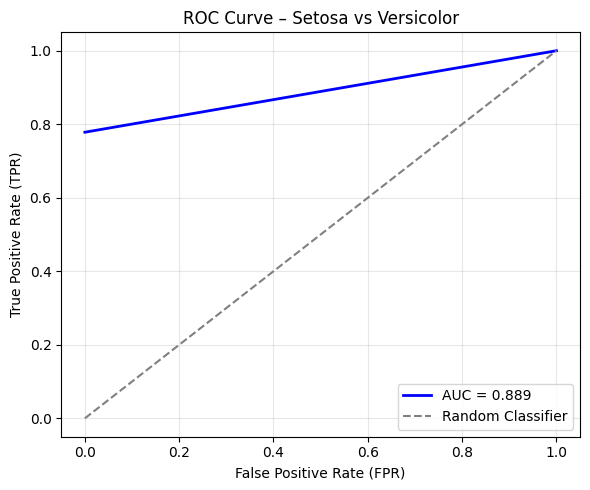

In [263]:
# --- Setosa vs Versicolor ---
results={}
labels_sv = (0, 1)

# Run cross-validation
avg_TPR_sv, avg_FPR_sv = cross_validation(data, class_labels=labels_sv, folds=10)

# Convert to arrays
avg_TPR_sv = np.array(avg_TPR_sv)
avg_FPR_sv = np.array(avg_FPR_sv)

# Calculate AUC manually
auc_sv = sum((avg_FPR_sv[i] - avg_FPR_sv[i-1]) * (avg_TPR_sv[i] + avg_TPR_sv[i-1]) / 2 
             for i in range(1, len(avg_FPR_sv)))
print(f"Setosa vs Versicolor: Average AUC = {auc_sv:.3f}")
# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(avg_FPR_sv, avg_TPR_sv, color="blue", linewidth=2, label=f"AUC = {auc_sv:.3f}")
plt.plot([0,1],[0,1],"--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve – Setosa vs Versicolor")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC


# Store for combined plot
results["Setosa vs Versicolor"] = (avg_TPR_sv, avg_FPR_sv, auc_sv)


Setosa vs Virginica: Average AUC = 0.838


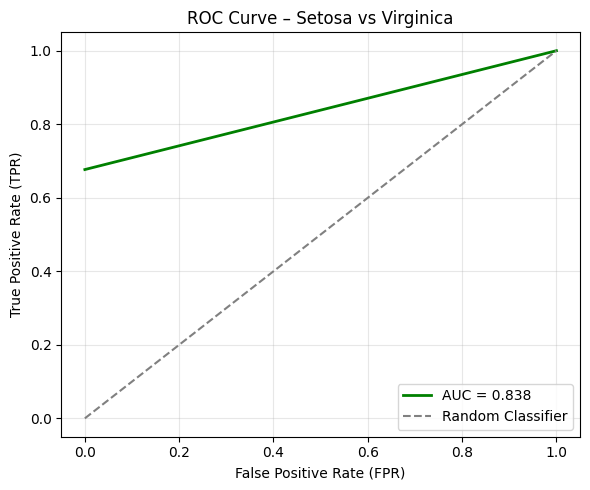

In [265]:
# --- Setosa vs Virginica ---
results={}
labels_sv2 = (0, 2)

avg_TPR_sv2, avg_FPR_sv2 = cross_validation(data, class_labels=labels_sv2, folds=10)
avg_TPR_sv2 = np.array(avg_TPR_sv2)
avg_FPR_sv2 = np.array(avg_FPR_sv2)

auc_sv2 = sum((avg_FPR_sv2[i] - avg_FPR_sv2[i-1]) * (avg_TPR_sv2[i] + avg_TPR_sv2[i-1]) / 2 
              for i in range(1, len(avg_FPR_sv2)))
print(f"Setosa vs Virginica: Average AUC = {auc_sv2:.3f}")
plt.figure(figsize=(6,5))
plt.plot(avg_FPR_sv2, avg_TPR_sv2, color="green", linewidth=2, label=f"AUC = {auc_sv2:.3f}")
plt.plot([0,1],[0,1],"--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve – Setosa vs Virginica")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

results["Setosa vs Virginica"] = (avg_TPR_sv2, avg_FPR_sv2, auc_sv2)


Versicolor vs Virginica: Average AUC = 0.820


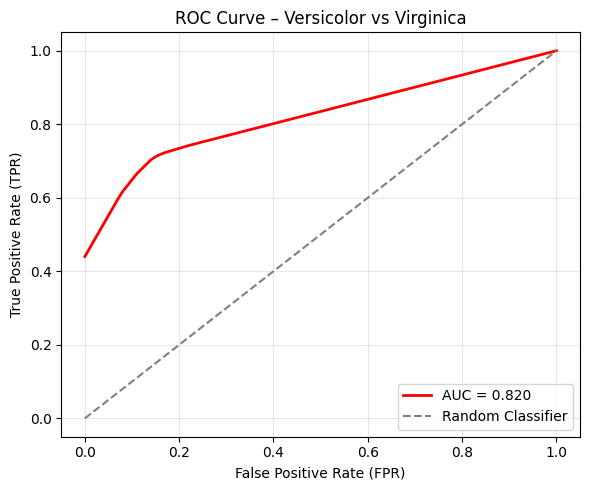

In [267]:
# --- Versicolor vs Virginica ---
results={}
labels_vv = (1, 2)

avg_TPR_vv, avg_FPR_vv = cross_validation(data, class_labels=labels_vv, folds=10)
avg_TPR_vv = np.array(avg_TPR_vv)
avg_FPR_vv = np.array(avg_FPR_vv)

auc_vv = sum((avg_FPR_vv[i] - avg_FPR_vv[i-1]) * (avg_TPR_vv[i] + avg_TPR_vv[i-1]) / 2 
             for i in range(1, len(avg_FPR_vv)))
print(f"Versicolor vs Virginica: Average AUC = {auc_vv:.3f}")
plt.figure(figsize=(6,5))
plt.plot(avg_FPR_vv, avg_TPR_vv, color="red", linewidth=2, label=f"AUC = {auc_vv:.3f}")
plt.plot([0,1],[0,1],"--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve – Versicolor vs Virginica")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

results["Versicolor vs Virginica"] = (avg_TPR_vv, avg_FPR_vv, auc_vv)


# Questions for examination:

In addition to completing the assignment with all its tasks, you should also prepare to answer the following questions:

1) Why is it called "naive bayes"?

2) What are some downsides of the naive bayes learning algorithm?

3) When using ROC-curves, what is the theoretical best and worst result you can get?

4) When using ROC-curves, in this assignment for example, is a higher threshold-stepsize always better?  


# Finished!

Was part of the setup incorrect? Did you spot any inconsistencies in the assignment? Could something improve?

If so, please write them and send via email and send it to:

* marcus.gullstrand@ju.se

Thank you!